# EDA — jeu NIST 14 & 16 SEER

Campagne NIST *FDD Heat Pump Cooling*, 7375 essais en chambre climatique sur deux machines,
défauts imposés. Objectif : savoir si ces mesures peuvent confronter — voire remplacer — les
données simulées du projet.

Mapping de référence : `docs/NIST_MAPPING.md`.

**Plan** — 1 charger · 2 étiqueter · 3 convertir · 4 couvrir les features · 5 recouvrement des
domaines *(section décisive)* · 6 verdict.


> **Données non versionnées.** Les deux classeurs NIST (8,5 Mo) ne sont pas dans le dépôt.
> Les télécharger depuis la page publique NIST *Fault Detection and Diagnosis Research Data*
> (URL dans `docs/NIST_MAPPING.md`) et les placer dans `data/nist/` :
>
> - `fdd_1416seer.xlsx` — les 7375 essais
> - `fdd_1416seer_desc.xlsx` — le dictionnaire des 98 colonnes


## 0 — Amorce

Le cwd d'un notebook VS Code est **son propre dossier**, pas la racine du repo. On résout
la racine par un marqueur pour que tout marche d'où qu'on lance.


In [5]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'requirements.txt').exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
NIST = ROOT / 'data' / 'nist'

# palette validée (slots 1-3, all-pairs OK en clair)
BLUE, ORANGE, AQUA = '#2a78d6', '#eb6834', '#1baf7a'
INK, MUTED, GRID = '#0b0b0b', '#52514e', '#e4e3df'
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.edgecolor': GRID, 'axes.labelcolor': MUTED, 'text.color': INK,
    'xtick.color': MUTED, 'ytick.color': MUTED, 'axes.grid': True,
    'grid.color': GRID, 'grid.linewidth': 0.8, 'axes.axisbelow': True,
    'axes.spines.top': False, 'axes.spines.right': False, 'font.size': 10,
})
print('ROOT =', ROOT.name)


ROOT = heat-pump-fdd


## 1 — Charger

⚠️ Ne pas confondre avec `data/nistir_7350_…(NF).csv` : 67 lignes, **sans défaut uniquement**,
lu par aucun code du projet. Le jeu utile est dans `data/nist/`.

Le dictionnaire des colonnes est dans un onglet nommé — le premier onglet du classeur est vide.


In [6]:
df = pd.read_excel(NIST / 'fdd_1416seer.xlsx')
labels = pd.read_excel(NIST / 'fdd_1416seer_desc.xlsx', sheet_name='Label Definitions')

print(f'essais   : {df.shape[0]} lignes x {df.shape[1]} colonnes')
print(f'machines : {dict(df["Rated_SEER"].value_counts())}')
print(f'lineset  : {dict(df["Long/Short (0/1)"].value_counts())}   (0 = 50 ft, 1 = long)')


essais   : 7375 lignes x 98 colonnes
machines : {16.0: np.int64(4085), 14.0: np.int64(3289)}
lineset  : {0.0: np.int64(3742), 1.0: np.int64(3632)}   (0 = 50 ft, 1 = long)


## 2 — Reconstruire une étiquette unique

Les classes ne sont pas dans une colonne : elles sont **implicites**, réparties sur cinq
colonnes de niveau où 100 % = nominal.

| Colonne | Signification |
|---|---|
| `NF` | drapeau sans défaut |
| `EF` | débit d'air **intérieur**, % du nominal |
| `CF` | **obstruction** de la face du serpentin extérieur, % dégagé |
| `LL` | perte de charge ligne liquide |
| `UC/OC` | charge de fluide, % du nominal |

Un défaut est actif si son niveau s'écarte de plus de **2 %** du nominal.


In [7]:
FAULTCOLS = {'EF': 'Evap_Airflow', 'CF': 'Cond_Blockage', 'LL': 'LiquidLine', 'UC/OC': 'Charge'}
TOL = 2.0

def fault_label(row):
    active = []
    for col, name in FAULTCOLS.items():
        v = row[col]
        if pd.isna(v) or abs(v - 100) <= TOL:
            continue
        if name == 'Charge':
            name = 'Undercharge' if v < 100 else 'Overcharge'
        active.append(name)
    if not active:
        return 'No_Fault'
    return active[0] if len(active) == 1 else 'MULTI:' + '+'.join(sorted(active))

df['fault_class'] = df.apply(fault_label, axis=1)
single = df[~df.fault_class.str.startswith('MULTI')]

ATTENDU = {'No_Fault': 1353, 'Undercharge': 1228, 'Overcharge': 942,
           'Evap_Airflow': 774, 'LiquidLine': 593, 'Cond_Blockage': 497}
vc = df.fault_class.value_counts()
assert all(vc.get(k) == v for k, v in ATTENDU.items()), 'tolérance à revoir'
print(f'✅ comptes conformes — {len(single)} lignes mono-défaut, {len(df) - len(single)} multi-défaut')
vc.to_frame('lignes')


✅ comptes conformes — 5387 lignes mono-défaut, 1988 multi-défaut


,lignes
fault_class,
No_Fault,1353
Undercharge,1228
MULTI:Evap_Airflow+Undercharge,1020
MULTI:Cond_Blockage+Evap_Airflow,968
Overcharge,942
Evap_Airflow,774
LiquidLine,593
Cond_Blockage,497


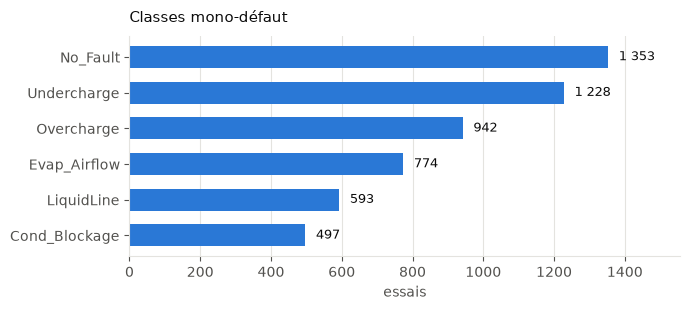

In [8]:
order = vc[~vc.index.str.startswith('MULTI')].sort_values()
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.barh(order.index, order.values, color=BLUE, height=0.62)
for y, v in enumerate(order.values):
    ax.text(v + 30, y, f'{v:,}'.replace(',', ' '), va='center', color=INK, fontsize=9)
ax.set_xlim(0, order.max() * 1.15)
ax.set_xlabel('essais'); ax.grid(axis='y', visible=False)
ax.set_title('Classes mono-défaut', loc='left', color=INK, fontsize=11, pad=10)
plt.tight_layout()


## 3 — Conversion SI

Le simulateur travaille en **bar, °C, K, W**. NIST tabule en unités US.


In [9]:
F2C   = lambda s: (s - 32) * 5 / 9   # température
dF2K  = lambda s: s * 5 / 9          # écart de température
PSI2BAR, BTU2W = 0.0689476, 0.293071

si = pd.DataFrame(index=df.index)
si['P_cond']      = df['CompDisch_psia'] * PSI2BAR
si['T_suction']   = F2C(df['1608_CompSuct_TempF'])
si['T_discharge'] = F2C(df['1617_CompDisch_TempF'])
si['T_evap']      = F2C(df['CompSuct_Tsat_F'])
si['T_cond']      = F2C(df['CompDisch_Tsat_F'])
si['superheat']   = dF2K(df['CompSuct_Suph_F'])
si['subcooling']  = dF2K(df['ODLiqSV_Tsub_F'])
si['Q_evap']      = df['TOTAL Capacity (Btu/h)'] * BTU2W
si['W_od']        = df['OD_Xitron_Watts']
si['COP']         = df['COP']
si['fault_class'] = df['fault_class']
si['seer']        = df['Rated_SEER']
si.head(3)


,P_cond,T_suction,T_discharge,T_evap,T_cond,superheat,subcooling,Q_evap,W_od,COP,fault_class,seer
0,19.042745,12.326237,59.841103,2.265722,30.428563,10.060516,3.310448,7881.088047,2054.75,3.168620,MULTI:Evap_Airflow+Undercharge,14.0
1,19.031260,12.385394,59.746902,2.277474,30.405101,10.107921,3.239597,7899.032949,2051.21,3.178246,MULTI:Evap_Airflow+Undercharge,14.0
2,21.486825,23.551783,69.559755,7.687649,35.195060,15.864134,2.751633,8972.754877,2241.28,3.361996,MULTI:Evap_Airflow+Undercharge,14.0


### 🔴 Piège capteur — la colonne d'aspiration est fausse sur la 16 SEER

Le nom `1710_ODSuctPort_psia` (« pression au port d'aspiration ») invite à l'utiliser comme
`P_evap`. C'est un piège : sur la machine 16 SEER elle est **identique au refoulement**.

Le capteur n'était pas instrumenté sur cette unité et la colonne a été remplie avec la
pression haute. Utilisée telle quelle, elle corrompt `P_evap`, `compression_ratio` et
`pressure_ratio` sur **55 % du jeu**, en silence.

La bonne colonne est `1701_ODVapSV_psia` (vanne de service vapeur), cohérente sur les deux
machines.


In [10]:
ident = df.groupby('Rated_SEER').apply(
    lambda g: np.isclose(g['1710_ODSuctPort_psia'], g['CompDisch_psia'], rtol=1e-6).mean() * 100,
    include_groups=False)
print('% de lignes où 1710_ODSuctPort == refoulement :')
print(ident.round(1).to_string())

for col in ['1710_ODSuctPort_psia', '1701_ODVapSV_psia']:
    ratio = df['CompDisch_psia'] / df[col]
    print(f'{col:24} ratio médian {ratio.median():.2f}   min {ratio.min():.2f}')

si['P_evap'] = df['1701_ODVapSV_psia'] * PSI2BAR   # ← colonne corrigée
si['pressure_ratio'] = si.P_cond / si.P_evap


% de lignes où 1710_ODSuctPort == refoulement :
Rated_SEER
14.0      0.0
16.0    100.0
1710_ODSuctPort_psia     ratio médian 1.00   min 1.00
1701_ODVapSV_psia        ratio médian 2.46   min 1.64


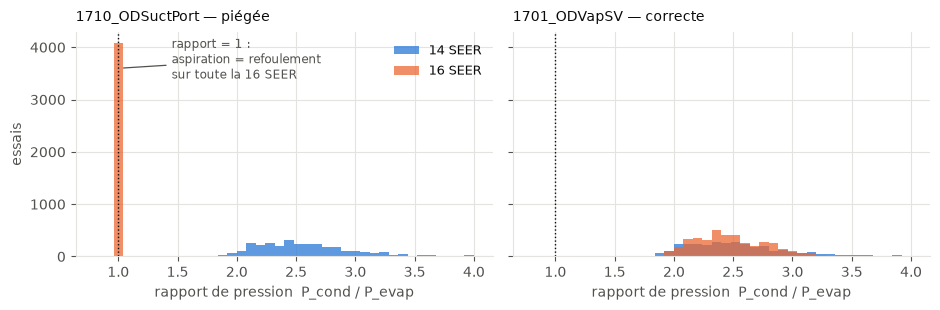

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.2), sharey=True)
for ax, col, titre in zip(axes,
        ['1710_ODSuctPort_psia', '1701_ODVapSV_psia'],
        ['1710_ODSuctPort — piégée', '1701_ODVapSV — correcte']):
    for seer, couleur in [(14.0, BLUE), (16.0, ORANGE)]:
        r = (df.CompDisch_psia / df[col])[df.Rated_SEER == seer]
        ax.hist(r, bins=40, range=(0.8, 4), color=couleur, alpha=0.75,
                label=f'{seer:.0f} SEER', linewidth=0)
    ax.axvline(1.0, color=INK, linewidth=1, linestyle=':')
    ax.set_title(titre, loc='left', fontsize=10, color=INK, pad=8)
    ax.set_xlabel('rapport de pression  P_cond / P_evap')
axes[0].set_ylabel('essais'); axes[0].legend(frameon=False, fontsize=9)
axes[0].annotate('rapport = 1 :\naspiration = refoulement\nsur toute la 16 SEER',
                 xy=(1.02, 3600), xytext=(1.45, 3400), fontsize=8.5, color=MUTED,
                 arrowprops=dict(arrowstyle='-', color=MUTED, linewidth=0.9))

plt.tight_layout()


### Contrôle de bon sens

Sur les essais sains, les ordres de grandeur doivent être ceux d'un cycle R-410A.


In [12]:
nf = si[si.fault_class == 'No_Fault']
BORNES = {'P_evap': (6, 14, 'bar'), 'P_cond': (18, 40, 'bar'), 'pressure_ratio': (1.5, 4, '-'),
          'COP': (2, 6, '-'), 'superheat': (0, 20, 'K'), 'subcooling': (0, 20, 'K'),
          'T_discharge': (50, 110, '°C')}
rows = []
for c, (lo, hi, u) in BORNES.items():
    p5, med, p95 = nf[c].quantile([.05, .5, .95])
    rows.append({'grandeur': c, 'p5': round(p5, 2), 'médiane': round(med, 2),
                 'p95': round(p95, 2), 'unité': u, 'plausible': '✅' if lo <= med <= hi else '⚠️'})
pd.DataFrame(rows).set_index('grandeur')


,p5,médiane,p95,unité,plausible
grandeur,,,,,
P_evap,9.01,10.39,12.44,bar,✅
P_cond,19.20,25.47,32.90,bar,✅
pressure_ratio,1.92,2.37,3.00,-,✅
COP,2.33,3.41,4.68,-,✅
superheat,5.21,7.49,13.64,K,✅
subcooling,2.44,5.18,6.06,K,✅
T_discharge,52.12,67.40,86.17,°C,✅


## 4 — Couverture des 24 features

Le contrat du modèle est `FEATURE_COLUMNS` dans `src/fdd/features.py`.


In [13]:
from src.fdd.features import FEATURE_COLUMNS

DERIVABLES = {'compression_ratio', 'pressure_ratio', 'COP', 'delta_T_evap', 'delta_T_cond',
              'capacity_ratio', 'T_ambient', 'T_setpoint', 'Q_cond', 'W_comp'}
RESIDUS = {f for f in FEATURE_COLUMNS if f.startswith('d_')}
couverte = set(si.columns) | DERIVABLES | RESIDUS
manquantes = [f for f in FEATURE_COLUMNS if f not in couverte]

print(f'{len(FEATURE_COLUMNS) - len(manquantes)} / {len(FEATURE_COLUMNS)} features atteignables')
print('manquantes :', manquantes or '—')
print()
print('→ le compresseur NIST est mono-vitesse : compressor_speed_ratio est constant,')
print('  alors que le modèle est entraîné sur speed_ratio ∈ (0.3, 1.0).')


23 / 24 features atteignables
manquantes : ['compressor_speed_ratio']

→ le compresseur NIST est mono-vitesse : compressor_speed_ratio est constant,
  alors que le modèle est entraîné sur speed_ratio ∈ (0.3, 1.0).


## 5 — 🔴 Recouvrement des domaines

**La section qui décide de la suite.**

En mode froid, l'évaporateur est le serpentin **intérieur** et le condenseur le serpentin
**extérieur**. Le simulateur du projet tourne en mode **chaud**, entraîné sur
`T_source ∈ (-10, 20) °C` et `T_sink ∈ (30, 55) °C`.

Question : les conditions NIST tombent-elles dans ce domaine ?


In [14]:
T_source = F2C(df['Inlet TC Grid AVG Temp (F)'])   # médium côté évaporateur
T_sink   = F2C(df['OD Air AVG DB (F)'])            # médium côté condenseur
SIM_SRC, SIM_SNK = (-10.0, 20.0), (30.0, 55.0)

dans_src = T_source.between(*SIM_SRC)
dans_snk = T_sink.between(*SIM_SNK)
dans_deux = dans_src & dans_snk

print(f'T_source  NIST [{T_source.min():5.1f}, {T_source.max():5.1f}] °C   sim {SIM_SRC}  → {100*dans_src.mean():5.1f}% dedans')
print(f'T_sink    NIST [{T_sink.min():5.1f}, {T_sink.max():5.1f}] °C   sim {SIM_SNK}  → {100*dans_snk.mean():5.1f}% dedans')
print(f'\ndans les DEUX plages : {dans_deux.sum()} / {len(df)}  ({100*dans_deux.mean():.1f} %)')


T_source  NIST [ 13.8,  37.2] °C   sim (-10.0, 20.0)  →  11.9% dedans
T_sink    NIST [ 18.8,  47.7] °C   sim (30.0, 55.0)  →  61.4% dedans

dans les DEUX plages : 392 / 7375  (5.3 %)


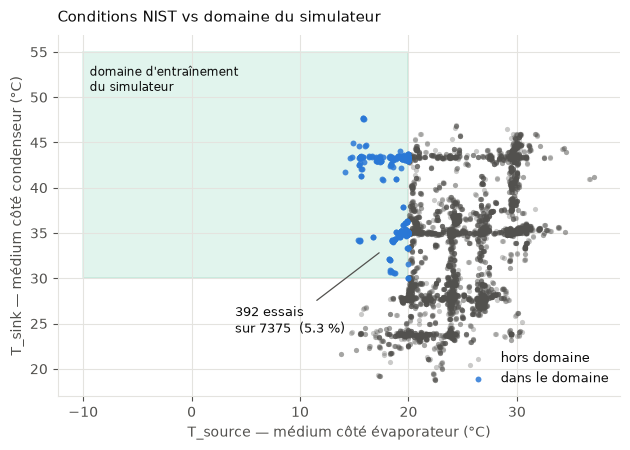

In [16]:
fig, ax = plt.subplots(figsize=(6.4, 4.6))
ax.add_patch(plt.Rectangle((SIM_SRC[0], SIM_SNK[0]), SIM_SRC[1]-SIM_SRC[0], SIM_SNK[1]-SIM_SNK[0],
                           facecolor=AQUA, alpha=0.13, edgecolor=AQUA, linewidth=1.4, zorder=0))
ax.scatter(T_source[~dans_deux], T_sink[~dans_deux], s=14, color=MUTED, alpha=0.30,
           linewidth=0, label='hors domaine', zorder=2)
ax.scatter(T_source[dans_deux], T_sink[dans_deux], s=18, color=BLUE, alpha=0.85,
           linewidth=0, label='dans le domaine', zorder=3)
ax.text(SIM_SRC[0]+0.6, SIM_SNK[1]-1.4, "domaine d'entraînement\ndu simulateur",
        fontsize=8.5, color=INK, va='top')
ax.annotate(f'{dans_deux.sum()} essais\nsur {len(df)}  ({100*dans_deux.mean():.1f} %)',
            xy=(17.5, 33), xytext=(4, 24), fontsize=9, color=INK,
            arrowprops=dict(arrowstyle='-', color=MUTED, linewidth=0.9))
ax.set_xlabel('T_source — médium côté évaporateur (°C)')
ax.set_ylabel('T_sink — médium côté condenseur (°C)')
ax.set_title('Conditions NIST vs domaine du simulateur', loc='left', fontsize=11, color=INK, pad=10)
ax.legend(frameon=False, fontsize=9, loc='lower right')
plt.tight_layout()


## 6 — Verdict

| Question | Réponse |
|---|---|
| Assez de volume pour réentraîner ? | **Oui** — 5387 lignes mono-défaut, 6 classes, équilibre 2,7:1 |
| Les 24 features sont-elles atteignables ? | **23/24** — `compressor_speed_ratio` hors d'atteinte |
| Comparaison en valeurs absolues ? | **Non** — ~5 % de recouvrement de domaine |
| Comparaison de pentes / signes ? | **Oui** — insensible au décalage de domaine |

**Deux pièges à ne jamais oublier**

1. `1710_ODSuctPort_psia` est inutilisable sur la 16 SEER — prendre `1701_ODVapSV_psia`.
2. Mode froid : extérieur = condenseur. Le sens s'inverse par rapport à TN 1648 (mode chaud).

**Suite** — sections 6 et 7 du plan : résidus mesurés via `cycle_to_features(..., baseline=...)`,
puis comparaison des pentes au balayage simulé de `fan_cond_ratio` / `fan_evap_ratio`.

Le livrable ne sera pas ce notebook mais un script reproductible plus un tableau de
concordance dans `docs/`.
